### Autograd in Pytorch

In [ ]:
import torch
# Creating the graph
x = torch.tensor(1.0, requires_grad = True)
z = x ** 3
z.backward() #Computes the gradient
print(x.grad.data) #Prints '3' which is dz/dx

tensor(3.)


In [ ]:
import torch

# Creating the graph
x = torch.tensor(1.0, requires_grad = True)
y = torch.tensor(2.0)
z = x * y
z.backward()

print ("dz/dx=",y,x.grad.data)

dz/dx= tensor(2.) tensor(2.)


In [ ]:
import torch

a = torch.tensor([2., 3.], requires_grad=True)
b = torch.tensor([6., 4.], requires_grad=True)
Q = 3*a**3 - b**2
external_grad = torch.tensor([1., 1.])
Q.backward(gradient=external_grad)
# check if collected gradients are correct
print(9*a**2 == a.grad)
print(-2*b == b.grad)

print (9*a**2)
print (a.grad.data)

tensor([True, True])
tensor([True, True])
tensor([36., 81.], grad_fn=<MulBackward0>)
tensor([36., 81.])


### Linear Regression

In [ ]:
import numpy as np# create dummy data for training
x_values = [i for i in range(20)]
x_train = np.array(x_values, dtype=np.float32)
x_train = x_train.reshape(-1, 1)

# y = 2*x + 1

y_values = [2*i + 1 for i in x_values]
y_train = np.array(y_values, dtype=np.float32)
y_train = y_train.reshape(-1, 1)

print (x_train.shape, y_train.shape)

import torch
from torch.autograd import Variable

class linearRegression(torch.nn.Module):
    def __init__(self, inputSize, outputSize):
        super(linearRegression, self).__init__()
        self.linear = torch.nn.Linear(inputSize, outputSize)

    def forward(self, x):
        out = self.linear(x)
        return out

inputDim = 1        # takes variable 'x'
outputDim = 1       # takes variable 'y'
learningRate = 0.0001
epochs = 1000

model = linearRegression(inputDim, outputDim)
##### For GPU #######
if torch.cuda.is_available():
    model.cuda()

criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

for epoch in range(epochs):
    # Converting inputs and labels to Variable
    if torch.cuda.is_available():
        inputs = Variable(torch.from_numpy(x_train).cuda())
        labels = Variable(torch.from_numpy(y_train).cuda())
    else:
        inputs = Variable(torch.from_numpy(x_train))
        labels = Variable(torch.from_numpy(y_train))

    # Clear gradient buffers because we don't want any gradient from previous epoch to carry forward, dont want to cummulate gradients
    optimizer.zero_grad()

    # get output from the model, given the inputs
    outputs = model(inputs)

    # get loss for the predicted output
    loss = criterion(outputs, labels)
    print(loss)
    # get gradients w.r.t to parameters
    loss.backward()

    # update parameters
    optimizer.step()

    print('epoch {}, loss {}'.format(epoch, loss.item()))

with torch.no_grad(): # we don't need gradients in the testing phase
    if torch.cuda.is_available():
        predicted = model(Variable(torch.from_numpy(x_train).cuda())).cpu().data.numpy()
    else:
        predicted = model(Variable(torch.from_numpy(x_train))).data.numpy()
    print(predicted)



(20, 1) (20, 1)
tensor(352.6179, grad_fn=<MseLossBackward0>)
epoch 0, loss 352.61785888671875
tensor(335.3131, grad_fn=<MseLossBackward0>)
epoch 1, loss 335.3131103515625
tensor(318.8576, grad_fn=<MseLossBackward0>)
epoch 2, loss 318.8575744628906
tensor(303.2096, grad_fn=<MseLossBackward0>)
epoch 3, loss 303.2095947265625
tensor(288.3295, grad_fn=<MseLossBackward0>)
epoch 4, loss 288.3294982910156
tensor(274.1797, grad_fn=<MseLossBackward0>)
epoch 5, loss 274.17974853515625
tensor(260.7244, grad_fn=<MseLossBackward0>)
epoch 6, loss 260.724365234375
tensor(247.9293, grad_fn=<MseLossBackward0>)
epoch 7, loss 247.9293212890625
tensor(235.7622, grad_fn=<MseLossBackward0>)
epoch 8, loss 235.76217651367188
tensor(224.1922, grad_fn=<MseLossBackward0>)
epoch 9, loss 224.19216918945312
tensor(213.1900, grad_fn=<MseLossBackward0>)
epoch 10, loss 213.18997192382812
tensor(202.7277, grad_fn=<MseLossBackward0>)
epoch 11, loss 202.72767639160156
tensor(192.7788, grad_fn=<MseLossBackward0>)
epoch 12

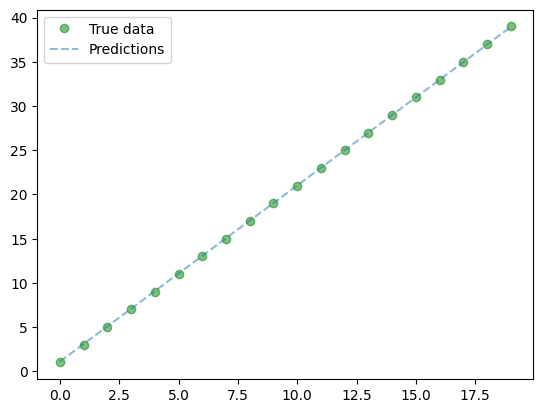

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.clf()
plt.plot(x_train, y_train, 'go', label='True data', alpha=0.5)
plt.plot(x_train, predicted, '--', label='Predictions', alpha=0.5)
plt.legend(loc='best')
plt.show()



### Logistic regression

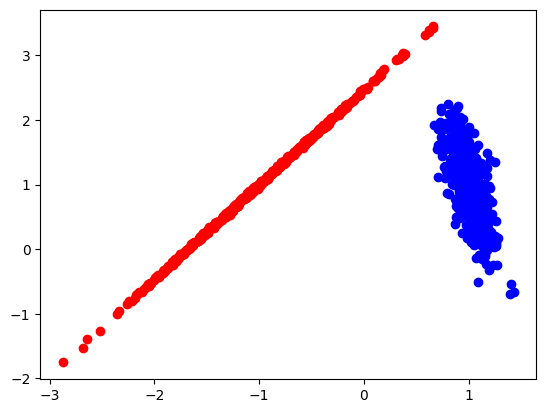

(1000, 2)
(1000,)


100%|██████████| 100000/100000 [00:50<00:00, 1984.05it/s]


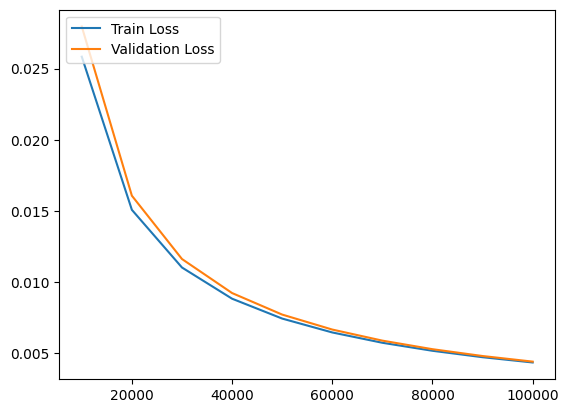

In [ ]:
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib
from tqdm import tqdm
import torch




from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

# Generate a random dataset, but linearly separable!!!
separable = False
while not separable:
    samples = make_classification(n_samples=1000, n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=1)
    red = samples[0][samples[1] == 0]
    blue = samples[0][samples[1] == 1]
    separable = any([red[:,k].max() < blue[:,k].min() or red[:,k].min() > blue[:,k].max() for k in range(2)])
    #print (separable)



plt.scatter(red[:,0], red[:,1], c='red', label='Class 0')
plt.scatter(blue[:,0], blue[:,1], c='blue', label='Class 1')
plt.show()

red_labels = np.zeros(len(red))
blue_labels = np.ones(len(blue))

labels = np.append(red_labels, blue_labels)
inputs = np.concatenate((red, blue), axis=0)

print (inputs.shape)
print (labels.shape)
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(inputs, labels, test_size=0.3, random_state=42)


class LogisticRegression (torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegression, self).__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)
    def forward(self, x):
        out = torch.sigmoid(self.linear(x))
        return out

epochs = 100000
input_dim = 2 # two features x1, x2
output_dim = 1
learning_rate = 0.01

model = LogisticRegression(input_dim, output_dim)
criterion = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_val = torch.from_numpy(X_val).float()
y_val = torch.from_numpy(y_val).float()

losses = []
losses_val = []

iters = []

iter = 0

for epoch in tqdm(range(epochs)):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(torch.squeeze(outputs), y_train)
    loss.backward()
    optimizer.step()
    iter += 1
    if iter % 10000 == 0:
        with torch.no_grad():

            outputs_val = model(X_val)
            loss_val = criterion(torch.squeeze(outputs_val), y_val)
            losses_val.append(loss_val.item())

            losses.append(loss.item())
            iters.append(iter)

            #print('Iteration: {}. Loss: {}. Val Loss: {}'.format(iter, loss.item(), loss_val.item()))

plt.clf()
plt.plot(iters, losses, label='Train Loss')
plt.plot(iters, losses_val, label='Validation Loss')
plt.legend(loc="upper left")
plt.show()

### Shallow neural network

(4000, 2)
(4000,)


Text(0, 0.5, 'feature 2')

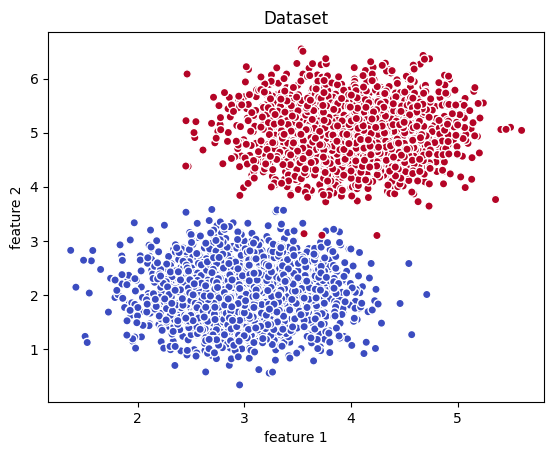

In [ ]:
# Necessary imports
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib.cm as cm

# This line detects if we have a gpu support on our system
device = ("cuda" if torch.cuda.is_available() else "cpu")

x1 = np.random.randn(2000)*0.5+3
x2 = np.random.randn(2000)*0.5+2

x3 = np.random.randn(2000) *0.5 + 4
x4 = np.random.randn(2000) *0.5 + 5

# Creating a Matrix
X_1 = np.vstack([x1, x2])
X_2 = np.vstack([x3, x4])
X = np.hstack([X_1, X_2]).T

# Creating a vector that contains classes (0, 1)
y = np.hstack([np.zeros(2000), np.ones(2000)])

print(X.shape)
print(y.shape)

plt.scatter(X[:,0], X[:,1], c=y, cmap=cm.coolwarm, edgecolors='w');
plt.title('Dataset')
plt.xlabel('feature 1')
plt.ylabel('feature 2')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

# converting the datatypes from numpy array into tensors of type float
X_train = torch.from_numpy(X_train).type(torch.FloatTensor)
X_test = torch.from_numpy(X_test).type(torch.FloatTensor)

y_train = torch.from_numpy(y_train.squeeze()).type(torch.FloatTensor).view(-1, 1)
y_test = torch.from_numpy(y_test.squeeze()).type(torch.FloatTensor).view(-1, 1)

# checking the shape
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

torch.Size([3200, 2])
torch.Size([800, 2])
torch.Size([3200, 1])
torch.Size([800, 1])


## Model definition

In [ ]:
class ShallowNeuralNetwork(nn.Module):
    def __init__(self, input_num, hidden_num, output_num):
        super(ShallowNeuralNetwork, self).__init__()
        self.hidden = nn.Linear(input_num, hidden_num) # hidden layer
        self.output = nn.Linear(hidden_num, output_num) # output layer
        #self.sigmoid = nn.Sigmoid() # sigmoid activation function
        self.relu = nn.ReLU() # relu activation function

    def forward(self, x):
        x = self.relu(self.hidden(x))
        out = self.output(x)
        return out

input_num = 2
hidden_num = 2
output_num = 1 # The output should be the same as the number of classes

model = ShallowNeuralNetwork(input_num, hidden_num, output_num)
model.to(device) # send our model to gpu if available else cpu.
print(model)

ShallowNeuralNetwork(
  (hidden): Linear(in_features=2, out_features=2, bias=True)
  (output): Linear(in_features=2, out_features=1, bias=True)
  (relu): ReLU()
)


## Training cycle

In [ ]:
!pip install tqdm
from tqdm import tqdm

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)

if torch.cuda.is_available():
    X_train = Variable(X_train).cuda()
    y_train = Variable(y_train).cuda()
    X_test = Variable(X_test).cuda()
    y_test = Variable(y_test).cuda()

num_epochs = 1000



total_acc, total_loss = [], []

for epoch in tqdm(range(num_epochs)):
    # forward propagation
    model.train()

    y_pred = model(X_train)
    pred = np.where(y_pred.cpu() > 0.5, 1, 0)
    loss = criterion(y_pred, y_train)

    # back propagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



    print('Epoch [{}/{}], Train Loss: {:.5f},'.format(epoch, num_epochs, loss.item()))
print('\nTraining Complete')

 21%|██        | 208/1000 [00:00<00:00, 1062.66it/s]

Epoch [0/1000], Train Loss: 0.73125,
Epoch [1/1000], Train Loss: 0.72817,
Epoch [2/1000], Train Loss: 0.72520,
Epoch [3/1000], Train Loss: 0.72248,
Epoch [4/1000], Train Loss: 0.71999,
Epoch [5/1000], Train Loss: 0.71777,
Epoch [6/1000], Train Loss: 0.71578,
Epoch [7/1000], Train Loss: 0.71403,
Epoch [8/1000], Train Loss: 0.71248,
Epoch [9/1000], Train Loss: 0.71110,
Epoch [10/1000], Train Loss: 0.70987,
Epoch [11/1000], Train Loss: 0.70876,
Epoch [12/1000], Train Loss: 0.70776,
Epoch [13/1000], Train Loss: 0.70686,
Epoch [14/1000], Train Loss: 0.70604,
Epoch [15/1000], Train Loss: 0.70527,
Epoch [16/1000], Train Loss: 0.70458,
Epoch [17/1000], Train Loss: 0.70394,
Epoch [18/1000], Train Loss: 0.70335,
Epoch [19/1000], Train Loss: 0.70279,
Epoch [20/1000], Train Loss: 0.70228,
Epoch [21/1000], Train Loss: 0.70179,
Epoch [22/1000], Train Loss: 0.70134,
Epoch [23/1000], Train Loss: 0.70092,
Epoch [24/1000], Train Loss: 0.70052,
Epoch [25/1000], Train Loss: 0.70014,
Epoch [26/1000], Train

 44%|████▎     | 437/1000 [00:00<00:00, 1108.51it/s]

Epoch [240/1000], Train Loss: 0.69322,
Epoch [241/1000], Train Loss: 0.69322,
Epoch [242/1000], Train Loss: 0.69321,
Epoch [243/1000], Train Loss: 0.69321,
Epoch [244/1000], Train Loss: 0.69321,
Epoch [245/1000], Train Loss: 0.69321,
Epoch [246/1000], Train Loss: 0.69321,
Epoch [247/1000], Train Loss: 0.69321,
Epoch [248/1000], Train Loss: 0.69321,
Epoch [249/1000], Train Loss: 0.69321,
Epoch [250/1000], Train Loss: 0.69321,
Epoch [251/1000], Train Loss: 0.69321,
Epoch [252/1000], Train Loss: 0.69321,
Epoch [253/1000], Train Loss: 0.69321,
Epoch [254/1000], Train Loss: 0.69321,
Epoch [255/1000], Train Loss: 0.69321,
Epoch [256/1000], Train Loss: 0.69321,
Epoch [257/1000], Train Loss: 0.69321,
Epoch [258/1000], Train Loss: 0.69321,
Epoch [259/1000], Train Loss: 0.69321,
Epoch [260/1000], Train Loss: 0.69321,
Epoch [261/1000], Train Loss: 0.69321,
Epoch [262/1000], Train Loss: 0.69321,
Epoch [263/1000], Train Loss: 0.69321,
Epoch [264/1000], Train Loss: 0.69321,
Epoch [265/1000], Train L

 67%|██████▋   | 668/1000 [00:00<00:00, 1136.26it/s]

Epoch [471/1000], Train Loss: 0.69317,
Epoch [472/1000], Train Loss: 0.69317,
Epoch [473/1000], Train Loss: 0.69317,
Epoch [474/1000], Train Loss: 0.69317,
Epoch [475/1000], Train Loss: 0.69317,
Epoch [476/1000], Train Loss: 0.69317,
Epoch [477/1000], Train Loss: 0.69317,
Epoch [478/1000], Train Loss: 0.69317,
Epoch [479/1000], Train Loss: 0.69317,
Epoch [480/1000], Train Loss: 0.69317,
Epoch [481/1000], Train Loss: 0.69317,
Epoch [482/1000], Train Loss: 0.69317,
Epoch [483/1000], Train Loss: 0.69317,
Epoch [484/1000], Train Loss: 0.69317,
Epoch [485/1000], Train Loss: 0.69317,
Epoch [486/1000], Train Loss: 0.69317,
Epoch [487/1000], Train Loss: 0.69317,
Epoch [488/1000], Train Loss: 0.69317,
Epoch [489/1000], Train Loss: 0.69317,
Epoch [490/1000], Train Loss: 0.69317,
Epoch [491/1000], Train Loss: 0.69317,
Epoch [492/1000], Train Loss: 0.69317,
Epoch [493/1000], Train Loss: 0.69317,
Epoch [494/1000], Train Loss: 0.69317,
Epoch [495/1000], Train Loss: 0.69317,
Epoch [496/1000], Train L

 90%|████████▉ | 899/1000 [00:00<00:00, 1140.03it/s]

Epoch [701/1000], Train Loss: 0.69316,
Epoch [702/1000], Train Loss: 0.69316,
Epoch [703/1000], Train Loss: 0.69316,
Epoch [704/1000], Train Loss: 0.69316,
Epoch [705/1000], Train Loss: 0.69316,
Epoch [706/1000], Train Loss: 0.69316,
Epoch [707/1000], Train Loss: 0.69316,
Epoch [708/1000], Train Loss: 0.69316,
Epoch [709/1000], Train Loss: 0.69316,
Epoch [710/1000], Train Loss: 0.69316,
Epoch [711/1000], Train Loss: 0.69316,
Epoch [712/1000], Train Loss: 0.69316,
Epoch [713/1000], Train Loss: 0.69316,
Epoch [714/1000], Train Loss: 0.69316,
Epoch [715/1000], Train Loss: 0.69316,
Epoch [716/1000], Train Loss: 0.69316,
Epoch [717/1000], Train Loss: 0.69316,
Epoch [718/1000], Train Loss: 0.69316,
Epoch [719/1000], Train Loss: 0.69316,
Epoch [720/1000], Train Loss: 0.69316,
Epoch [721/1000], Train Loss: 0.69316,
Epoch [722/1000], Train Loss: 0.69316,
Epoch [723/1000], Train Loss: 0.69316,
Epoch [724/1000], Train Loss: 0.69316,
Epoch [725/1000], Train Loss: 0.69315,
Epoch [726/1000], Train L

100%|██████████| 1000/1000 [00:00<00:00, 1114.28it/s]

Epoch [937/1000], Train Loss: 0.69315,
Epoch [938/1000], Train Loss: 0.69315,
Epoch [939/1000], Train Loss: 0.69315,
Epoch [940/1000], Train Loss: 0.69315,
Epoch [941/1000], Train Loss: 0.69315,
Epoch [942/1000], Train Loss: 0.69315,
Epoch [943/1000], Train Loss: 0.69315,
Epoch [944/1000], Train Loss: 0.69315,
Epoch [945/1000], Train Loss: 0.69315,
Epoch [946/1000], Train Loss: 0.69315,
Epoch [947/1000], Train Loss: 0.69315,
Epoch [948/1000], Train Loss: 0.69315,
Epoch [949/1000], Train Loss: 0.69315,
Epoch [950/1000], Train Loss: 0.69315,
Epoch [951/1000], Train Loss: 0.69315,
Epoch [952/1000], Train Loss: 0.69315,
Epoch [953/1000], Train Loss: 0.69315,
Epoch [954/1000], Train Loss: 0.69315,
Epoch [955/1000], Train Loss: 0.69315,
Epoch [956/1000], Train Loss: 0.69315,
Epoch [957/1000], Train Loss: 0.69315,
Epoch [958/1000], Train Loss: 0.69315,
Epoch [959/1000], Train Loss: 0.69315,
Epoch [960/1000], Train Loss: 0.69315,
Epoch [961/1000], Train Loss: 0.69315,
Epoch [962/1000], Train L

Accuracy Score on test data ==>> 49.75%


/tmp/ipykernel_16157/382034023.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[0].scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], label='Class 0', cmap=cm.coolwarm)
/tmp/ipykernel_16157/382034023.py:16: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[0].scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], label='Class 1', cmap=cm.coolwarm)
/tmp/ipykernel_16157/382034023.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[1].scatter(X_test[model_prediction==0, 0], X_test[model_prediction==0, 1], label='Class 0', cmap=cm.coolwarm)
/tmp/ipykernel_16157/382034023.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[1].scatter(X_test[model_prediction==1, 0], X_test[model_prediction==1, 1], label='Class 1', cmap=cm.coolwarm)


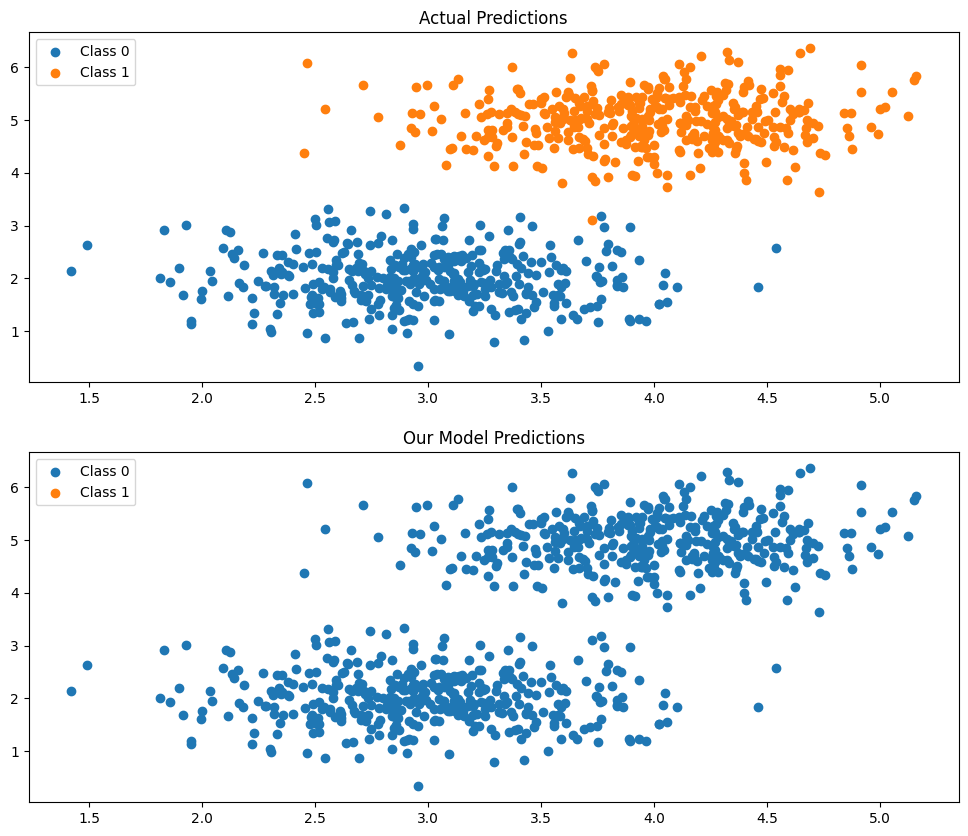

In [ ]:
model.eval()
model_prediction = model(X_test)

model_prediction = np.where(model_prediction.cpu() > 0.5, 1, 0)
model_prediction = model_prediction.reshape(-1)
print("Accuracy Score on test data ==>> {}%".format(accuracy_score(model_prediction, y_test.cpu()) * 100))


y_test = y_test.cpu()
X_test = X_test.cpu()
fig, ax = plt.subplots(2, 1, figsize=(12, 10))
y_test = y_test.view(-1)

# True Predictions
ax[0].scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], label='Class 0', cmap=cm.coolwarm)
ax[0].scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], label='Class 1', cmap=cm.coolwarm)
ax[0].set_title('Actual Predictions')
ax[0].legend()

# Models Predictions
ax[1].scatter(X_test[model_prediction==0, 0], X_test[model_prediction==0, 1], label='Class 0', cmap=cm.coolwarm)
ax[1].scatter(X_test[model_prediction==1, 0], X_test[model_prediction==1, 1], label='Class 1', cmap=cm.coolwarm)
ax[1].set_title('Our Model Predictions')
ax[1].legend()